In [4]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "../Scripts")
from util import color_plot

import torch
from deeptime.decomposition.deep import TAE
from deeptime.util.torch import MLP
from deeptime.decomposition.deep import TVAEEncoder
from torch.utils.data import DataLoader
from deeptime.util.data import TrajectoryDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler

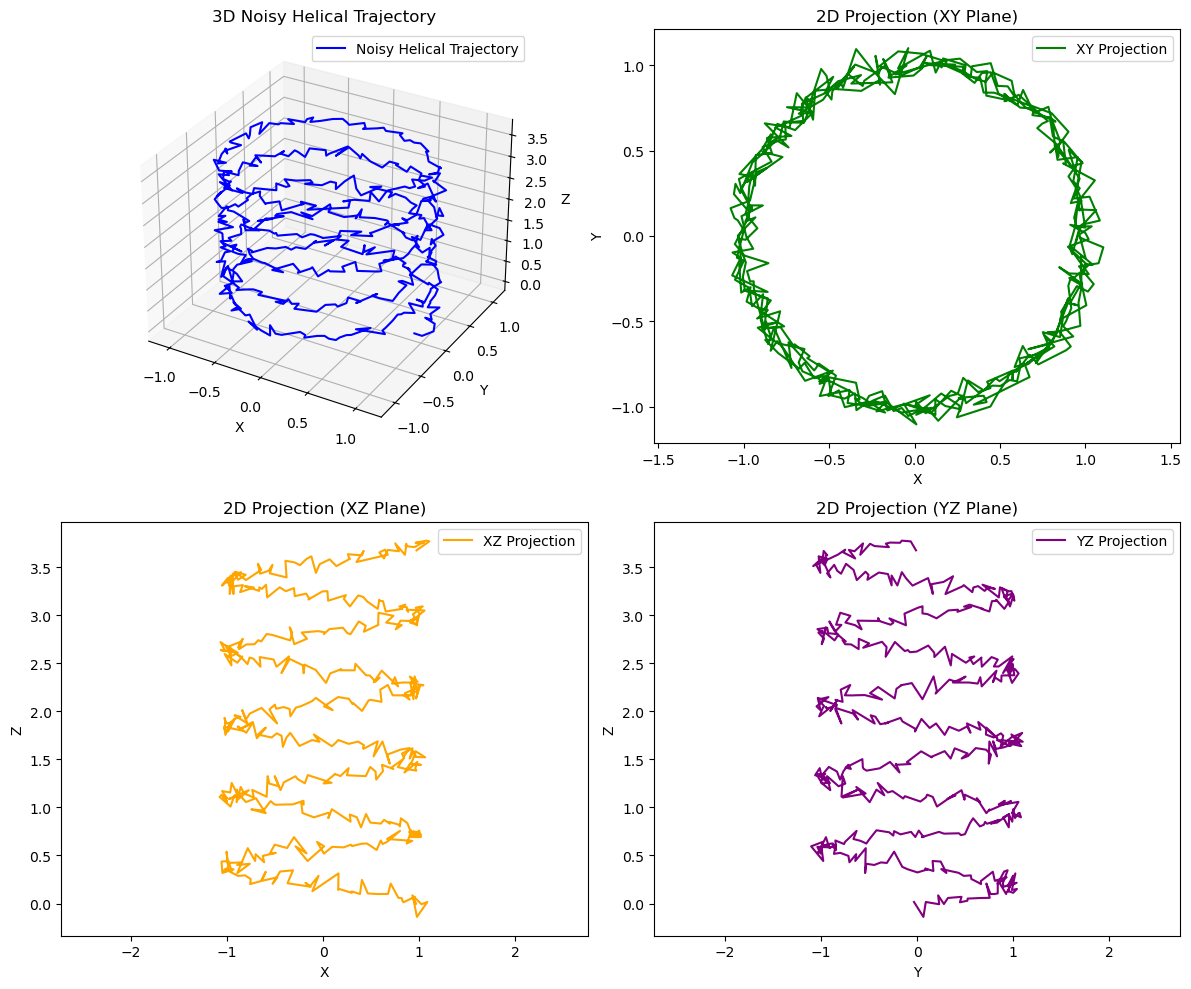

In [5]:
# Function to generate a noisy helical trajectory
def generate_noisy_helix(radius=1.0, pitch=0.75, turns=15, points_per_turn=100, noise_level=0.05):
    t = np.linspace(0, 2 * np.pi * turns, points_per_turn * turns)
    x = radius * np.cos(t) + np.random.normal(0, noise_level, t.shape)
    y = radius * np.sin(t) + np.random.normal(0, noise_level, t.shape)
    z = pitch * t / (2 * np.pi) + np.random.normal(0, noise_level, t.shape)
    return x, y, z

# Function to plot 3D trajectory and its 2D projection
def plot_helix_and_projection(x, y, z):
    fig = plt.figure(figsize=(12, 10))

    # 3D Plot
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.plot(x, y, z, label='Noisy Helical Trajectory', color='blue')
    ax1.set_title('3D Noisy Helical Trajectory')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()

    # 2D Projection (XY plane)
    ax2 = fig.add_subplot(222)
    ax2.plot(x, y, label='XY Projection', color='green')
    ax2.set_title('2D Projection (XY Plane)')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.axis('equal')
    ax2.legend()

    # 2D Projection (XZ plane)
    ax3 = fig.add_subplot(223)
    ax3.plot(x, z, label='XZ Projection', color='orange')
    ax3.set_title('2D Projection (XZ Plane)')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.axis('equal')
    ax3.legend()

    # 2D Projection (YZ plane)
    ax4 = fig.add_subplot(224)
    ax4.plot(y, z, label='YZ Projection', color='purple')
    ax4.set_title('2D Projection (YZ Plane)')
    ax4.set_xlabel('Y')
    ax4.set_ylabel('Z')
    ax4.axis('equal')
    ax4.legend()

    plt.tight_layout()
    plt.show()

# Generate and plot
x, y, z = generate_noisy_helix(turns=5)
plot_helix_and_projection(x, y, z)

In [24]:
## helical trajectory data
x, y, z = generate_noisy_helix(turns = 20)
data = np.column_stack([x, y, z])
scaler = StandardScaler()
data = scaler.fit_transform(data)
data = torch.Tensor(data)

In [38]:
dataset = TrajectoryDataset(1, data)
n_val = int(len(dataset)*.25)
train_data, val_data = torch.utils.data.random_split(dataset, [len(dataset) - n_val, n_val])
loader_train = DataLoader(train_data, batch_size=16, shuffle=True)
loader_val = DataLoader(val_data, batch_size=len(val_data), shuffle=False)
units = [3, 1024, 1024, 2]
encoder = MLP(units, nonlinearity=torch.nn.ReLU, output_nonlinearity=torch.nn.Sigmoid,
              initial_batchnorm=False)
decoder = MLP(units[::-1], nonlinearity=torch.nn.ReLU, initial_batchnorm=False)
tae = TAE(encoder, decoder, learning_rate=1e-3, device='cuda')
tae.fit(loader_train, n_epochs=100, validation_loader=loader_val)
tae_model = tae.fetch_model()

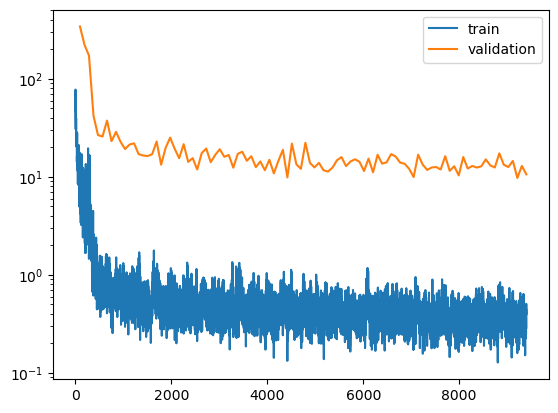

In [40]:
plt.semilogy(*tae.train_losses.T, label='train')
plt.semilogy(*tae.validation_losses.T, label='validation')
plt.legend();

Text(0, 0.5, '$\\mu_2$')

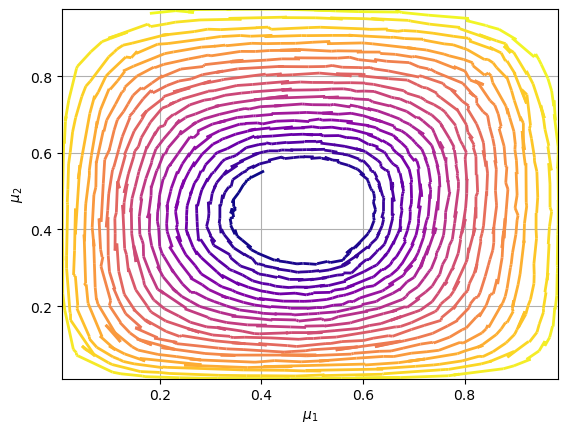

In [41]:
proj = tae_model.transform(data)
# fig, ax = plt.subplots(figsize=(8, 6))
color_plot(proj[:, 0], proj[:, 1])
plt.xlabel(r"$\mu_1$")
plt.ylabel(r"$\mu_2$")